# Polynôme de Minetti et al. (2002)

Tracé du coût énergétique de la course (Cr) en fonction de la pente,
d'après l'équation de Minetti et al. (2002), *J. Appl. Physiol.*, 93(3), 1039–1046.

$$C_r(i) = 155.4\,i^5 - 30.4\,i^4 - 43.3\,i^3 + 46.3\,i^2 + 19.5\,i + 3.6$$

où $i$ est le gradient (ex: 0.10 pour 10%), et $C_r$ est en J·kg⁻¹·m⁻¹.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
def minetti_cr(i):
    """Energy cost of running (J/kg/m) as a function of slope gradient.

    Minetti et al. (2002), J. Appl. Physiol., 93(3), 1039-1046.
    Valid for i in [-0.45, +0.45]; returns negative values below ~-0.55.

    Args:
        i: slope gradient (dimensionless, e.g. 0.10 for 10%)

    Returns:
        Cr in J/kg/m
    """
    return 155.4*i**5 - 30.4*i**4 - 43.3*i**3 + 46.3*i**2 + 19.5*i + 3.6

In [3]:
# --- Domaine valide de l'article ---
i_valid = np.linspace(-0.45, 0.45, 500)
cr_valid = minetti_cr(i_valid)

# --- Extension hors domaine (extrapolation) ---
i_extrap_neg = np.linspace(-0.65, -0.45, 100)
cr_extrap_neg = minetti_cr(i_extrap_neg)

i_extrap_pos = np.linspace(0.45, 0.60, 100)
cr_extrap_pos = minetti_cr(i_extrap_pos)

# --- Points expérimentaux reportés dans l'article ---
# (valeurs moyennes extraites du Tableau 2 et de la Figure 1 de l'article)
slopes_exp = np.array([-0.45, -0.40, -0.30, -0.20, -0.10, 0.00, 0.10, 0.20, 0.30, 0.40, 0.45])
cr_exp     = np.array([ 3.92,  3.30,  2.10,  1.73,  2.30,  3.40,  5.70,  8.90, 12.40, 16.50, 18.93])
cr_exp_sd  = np.array([ 0.81,  0.70,  0.50,  0.36,  0.40,  0.24,   0.60,  0.90,  1.10,  1.50,  1.74])

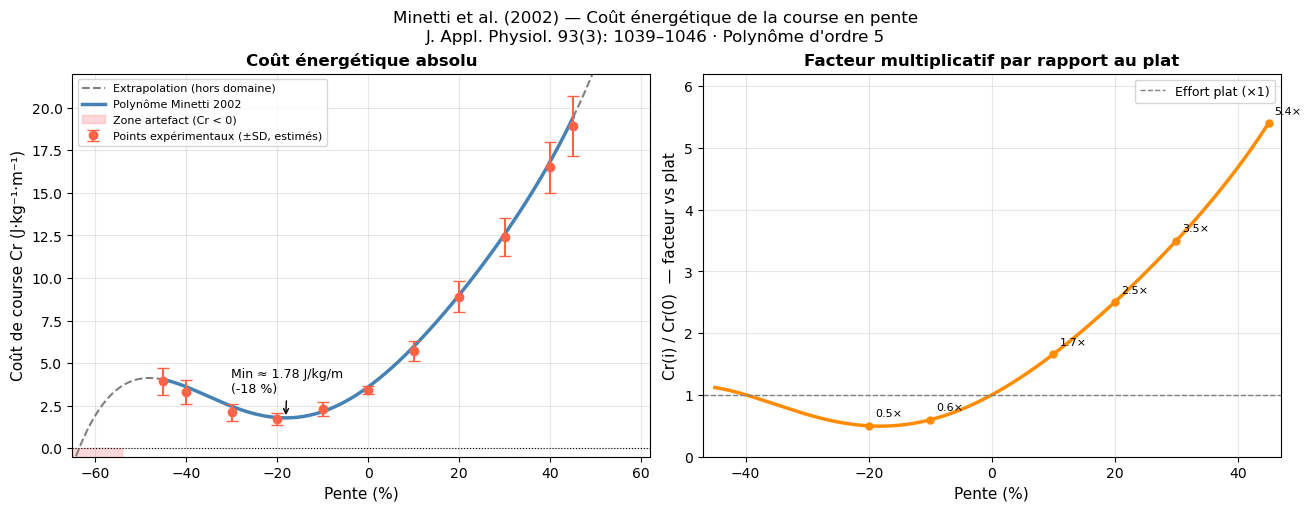

Figure sauvegardée : minetti_2002_curve.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# ------------------------------------------------------------------ #
# Panneau gauche : coût absolu Cr (J/kg/m)
# ------------------------------------------------------------------ #
ax = axes[0]

ax.plot(i_extrap_neg * 100, cr_extrap_neg, color='gray',
        linestyle='--', linewidth=1.5, label='Extrapolation (hors domaine)')
ax.plot(i_extrap_pos * 100, cr_extrap_pos, color='gray',
        linestyle='--', linewidth=1.5)
ax.plot(i_valid * 100, cr_valid, color='steelblue',
        linewidth=2.5, label='Polynôme Minetti 2002')
ax.errorbar(slopes_exp * 100, cr_exp, yerr=cr_exp_sd,
            fmt='o', color='tomato', markersize=6, capsize=4,
            label='Points expérimentaux (±SD, estimés)')

# Annotation du minimum
i_min = i_valid[np.argmin(cr_valid)]
cr_min = cr_valid.min()
ax.annotate(f'Min ≈ {cr_min:.2f} J/kg/m\n({i_min*100:.0f} %)',
            xy=(i_min * 100, cr_min),
            xytext=(i_min * 100 - 12, cr_min + 1.5),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9)

# Zone artefact polynôme (valeurs négatives)
i_neg_zone = np.linspace(-0.65, -0.54, 50)
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.fill_between(i_neg_zone * 100, -1, 0, color='red', alpha=0.15,
                label='Zone artefact (Cr < 0)')

ax.set_xlabel('Pente (%)', fontsize=11)
ax.set_ylabel('Coût de course Cr (J·kg⁻¹·m⁻¹)', fontsize=11)
ax.set_title('Coût énergétique absolu', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.set_xlim(-65, 62)
ax.set_ylim(-0.5, 22)
ax.grid(True, alpha=0.3)

# ------------------------------------------------------------------ #
# Panneau droit : rapport Cr(i) / Cr(0) — facteur multiplicatif vs plat
# ------------------------------------------------------------------ #
ax2 = axes[1]

cr_flat = minetti_cr(0.0)
ratio = cr_valid / cr_flat

ax2.plot(i_valid * 100, ratio, color='darkorange', linewidth=2.5)
ax2.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='Effort plat (×1)')

# Annotations efforts clés
for slope_pct, label in [(-20, '−20 %'), (-10, '−10 %'),
                          (10, '+10 %'), (20, '+20 %'),
                          (30, '+30 %'), (45, '+45 %')]:
    i_val = slope_pct / 100
    r = minetti_cr(i_val) / cr_flat
    ax2.annotate(f'{r:.1f}×', xy=(slope_pct, r),
                 xytext=(slope_pct + 1, r + 0.15),
                 fontsize=8, color='black')
    ax2.plot(slope_pct, r, 'o', color='darkorange', markersize=5)

ax2.set_xlabel('Pente (%)', fontsize=11)
ax2.set_ylabel('Cr(i) / Cr(0)  — facteur vs plat', fontsize=11)
ax2.set_title('Facteur multiplicatif par rapport au plat', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_xlim(-47, 47)
ax2.set_ylim(0, 6.2)
ax2.grid(True, alpha=0.3)

fig.suptitle(
    'Minetti et al. (2002) — Coût énergétique de la course en pente\n'
    'J. Appl. Physiol. 93(3): 1039–1046 · Polynôme d\'ordre 5',
    fontsize=12
)

plt.savefig('minetti_2002_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : minetti_2002_curve.png')

In [5]:
# --- Table des valeurs clés ---
print(f"{'Pente (%)':>10}  {'Cr (J/kg/m)':>12}  {'Facteur vs plat':>16}")
print('-' * 44)
for slope_pct in [-45, -30, -20, -10, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45]:
    i = slope_pct / 100
    cr = minetti_cr(i)
    ratio = cr / cr_flat
    print(f"{slope_pct:>10}  {cr:>12.2f}  {ratio:>16.2f}")

 Pente (%)   Cr (J/kg/m)   Facteur vs plat
--------------------------------------------
       -45          4.03              1.12
       -30          2.46              0.68
       -20          1.80              0.50
       -10          2.15              0.60
         0          3.60              1.00
         5          4.69              1.30
        10          5.97              1.66
        15          7.42              2.06
        20          9.01              2.50
        25         10.73              2.98
        30         12.58              3.49
        35         14.60              4.06
        40         16.85              4.68
        45         19.43              5.40
